In [2]:
from dotenv import load_dotenv
load_dotenv()

True

In [3]:
from langchain_community.document_loaders import PyPDFLoader
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_groq import ChatGroq
from langchain_google_genai import GoogleGenerativeAIEmbeddings
from langchain_community.vectorstores import InMemoryVectorStore

from langgraph.graph import  StateGraph , START , END
from pydantic import BaseModel ,Field


c:\Users\TECH DRONA\Desktop\GEN_Ai\env\Lib\site-packages\langchain_core\_api\deprecation.py:25: UserWarning: Core Pydantic V1 functionality isn't compatible with Python 3.14 or greater.
  from pydantic.v1.fields import FieldInfo as FieldInfoV1


In [4]:
## Document Load

loader = PyPDFLoader("../data/medical_report.pdf")
docs = loader.load()


## split - chunks
splitter = RecursiveCharacterTextSplitter(chunk_size = 1000 , chunk_overlap = 200)
docs = splitter.split_documents(docs)

## embeddings and vector DB
embed = GoogleGenerativeAIEmbeddings(model="gemini-embedding-2")
vector_Store = InMemoryVectorStore.from_documents(
    documents=docs,
    embedding=embed
)

In [5]:
class RagState(BaseModel):
    question:str = Field(description="User Questions")
    documents : list = []
    context : str = Field(description="conetext data for user question",default="")
    answer : str = Field(description="Final Answer..",default="")

In [6]:
llm = ChatGroq(model="openai/gpt-oss-20b")

In [7]:
# question -> retrieve -> context -> generate -> end

def retrive_node(state:RagState) -> RagState:
    docs = vector_Store.similarity_search(query=state.question)
    state.documents = docs
    return state

def create_context(state:RagState) -> RagState:
    context = ""
    for doc in state.documents:
        context += doc.page_content + "\n\n"
    state.context = context
    return state


def generate_node(state:RagState) -> RagState:
    prompt = f"""
        you are assistant and provide the answer for user question based on the provided context
        If you dont find the relevant answer ,  then just say ' I Dont Know. '
        context is: {state.context},
        Question is: {state.question}
    """
    res = llm.invoke(prompt)
    state.answer = res.content
    return state




In [8]:
graph = StateGraph(RagState)

graph.add_node("retrive_node",retrive_node)
graph.add_node("create_context_node",create_context)
graph.add_node("generate_node",generate_node)

graph.add_edge(START,'retrive_node')
graph.add_edge('retrive_node','create_context_node')
graph.add_edge('create_context_node','generate_node')
graph.add_edge('generate_node',END)


graph = graph.compile()

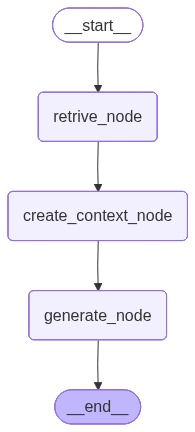

In [9]:
from IPython.display import Image
Image(graph.get_graph().draw_mermaid_png())

In [13]:
res = graph.invoke({"question":"what is the name and age of patient ?"})

In [14]:
print(res["answer"])

Name: Nikita Chudhary  
Age: 27 years
